In [1]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

Continued: <br>
/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023_downsampling_analyses_part2.ipynb <br>

## Old method: Generate a union list of loops by overlapping loops called from each individual libraries at 5kb resolution (without filtering)

### Call loops at 5kb resolution for each individual library (without filtering)

In [6]:
depth=['2000M', '1500M', '1000M', '500M']
output_folder='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/'
for dep in depth:
    input_cooler_paths=f'{output_folder}cooler_paths_of_Bond_et_al_2023_cis_{dep}.tsv'
    output_folder_depth=f'{output_folder}unionloops_5kb_old_cis_{dep}'

#     !bsub -q "long" -W 32:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 8 -R "rusage[mem=8000]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Generate_dots_from_each_individual_libraries_no_HiCCUPS_filtering.py $input_cooler_paths $output_folder_depth"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <280392> is submitted to queue <long>.
INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <280393> is submitted to queue <long>.
INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <280394> is submitted to queue <long>.
INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <280395> is submitted to queue <long>.


### Merge loops called from each individual library

In [1]:
import bioframe
import pandas as pd
import numpy as np

def merge_dots(df):
    overlapped_anchors_left=bioframe.cluster(df[['chrom1','start1','end1']].copy().rename(columns={'chrom1': 'chrom', 'start1': 'start', 'end1': 'end'}), min_dist=None)
    overlapped_anchors_right=bioframe.cluster(df[['chrom2','start2','end2','sample_name']].copy().rename(columns={'chrom2': 'chrom', 'start2': 'start', 'end2': 'end'}), min_dist=None)
    overlapped_dots=pd.merge(overlapped_anchors_left, overlapped_anchors_right, left_index=True, right_index=True, suffixes=(1,2))
    sample_name=overlapped_dots.groupby(['cluster1','cluster2'])['sample_name'].apply(lambda x: '&'.join(list(np.unique(x)))).reset_index()
    overlapped_dots=pd.merge(overlapped_dots[['cluster1','cluster2','chrom1','cluster_start1','cluster_end1','chrom2','cluster_start2','cluster_end2']], sample_name, on=['cluster1','cluster2'])
    overlapped_dots=overlapped_dots.drop(['cluster1', 'cluster2'], axis=1).rename(columns={'cluster_start1': 'start1', 'cluster_end1': 'end1', 'cluster_start2': 'start2', 'cluster_end2': 'end2'})
    overlapped_dots=overlapped_dots.drop_duplicates().reset_index(drop=True)
    return overlapped_dots


In [2]:
depth=['2000M', '1500M', '1000M', '500M']

for dep in depth:
    dots_dir=f'/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_{dep}/'
    dots_meta=pd.read_csv(dots_dir+'dots_meta_5kb_no_HiCCUPS_filtering.tsv', sep='\t')
    dots_list=[]
    for i in range(len(dots_meta)):
        df=pd.read_csv(dots_meta.path[i], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
        df['sample_name']=dots_meta.name[i]
        dots_list.append(df)
    dots=pd.concat(dots_list)
    merged_dots=merge_dots(dots)
#     merged_dots.to_csv(dots_dir+f'union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering_cis_{dep}.txt', sep='\t', index=False, header=True)

    

## Calculate numbers of overlapped and rescued loops at different depths

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
depth=['2500M','2000M','1500M','1000M','500M']

cluster_file_new={'2500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv',
                  '2000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_2000M/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv',
                  '1500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_1500M/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv',
                  '1000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_1000M/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv',
                  '500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_500M/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'}

dots_file_old={'2500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt',
               '2000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_2000M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_cis_2000M.txt',
               '1500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_1500M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_cis_1500M.txt',
               '1000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_1000M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_cis_1000M.txt',
               '500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_500M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_cis_500M.txt'}

# /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt
# generated in /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023_compare_loops_per_time_point_between_old_and_new_methods_updated.ipynb
dots_file_old_no_filtering={'2500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt',
                            '2000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_2000M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering_cis_2000M.txt',
                            '1500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_1500M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering_cis_1500M.txt',
                            '1000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_1000M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering_cis_1000M.txt',
                            '500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_old_cis_500M/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering_cis_500M.txt'}

dots_file_new={'2500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv',
               '2000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_2000M/results/Bond_et_al_2023_union_loop_list_5kb_cis_2000M.tsv',
               '1500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_1500M/results/Bond_et_al_2023_union_loop_list_5kb_cis_1500M.tsv',
               '1000M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_1000M/results/Bond_et_al_2023_union_loop_list_5kb_cis_1000M.tsv',
               '500M': '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/downsampling_analyses/unionloops_5kb_new_cis_500M/results/Bond_et_al_2023_union_loop_list_5kb_cis_500M.tsv'}


In [3]:
overlapped_loops_per_depth={}
for dep in depth:
    cluster_new=pd.read_csv(cluster_file_new[dep], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','condition','c_label','c_size']]
    dots_old=pd.read_csv(dots_file_old[dep], sep='\t')
    # remove MEGA only loops
    dots_old=dots_old.loc[dots_old.sample_name != 'MEGA']
    dots_new=pd.read_csv(dots_file_new[dep], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','sample_name']]
    # remove MEGA only loops
    dots_new=dots_new.loc[dots_new.sample_name != 'MEGA']
    
    dots_old_in_cluster_new=pd.merge(dots_old, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])
    dots_new_in_cluster_new=pd.merge(dots_new, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])
    
    conditions=['K562_0000min',
                'K562_0360min',
                'K562_4320min']
    overlapped_loops={}
    for cond in conditions:
        overlapped_loops[cond]={}
        # left: old; right: new
        df=pd.merge(dots_old_in_cluster_new.loc[dots_old_in_cluster_new.sample_name.str.contains(cond)],
                    dots_new_in_cluster_new.loc[dots_new_in_cluster_new.sample_name.str.contains(cond)],
                    on=['region','c_label','c_size'],
                    how="outer",
                    indicator=True)
        
        # filtered loops (old)
        dots_old_no_filtering=pd.read_csv(dots_file_old_no_filtering[dep], sep='\t')
        dots_old_no_filtering=dots_old_no_filtering.loc[dots_old_no_filtering.sample_name.str.contains(cond), ['chrom1','start1','end1','chrom2','start2','end2']]
        dots_old_no_filtering_in_cluster_new=pd.merge(dots_old_no_filtering, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])
        
        columns_to_convert=['start1','end1','start2','end2']

        df_old_only=df.loc[df._merge == 'left_only', ['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
        df_old_only[columns_to_convert] = df_old_only[columns_to_convert].astype(int)
        overlapped_loops[cond]['old_only']=df_old_only

        df_new_only=df.loc[df._merge == 'right_only', ['chrom1_y', 'start1_y', 'end1_y', 'chrom2_y', 'start2_y', 'end2_y', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
        df_new_only[columns_to_convert] = df_new_only[columns_to_convert].astype(int)
        overlapped_loops[cond]['new_only_in_new']=df_new_only

        # find filtered loops (old) in new only clusters
        df_dots_old_no_filtering_in_new_only_clusters=pd.merge(dots_old_no_filtering_in_cluster_new, df_new_only, on=['region','c_label','c_size'])[['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
        df_dots_old_no_filtering_in_new_only_clusters[columns_to_convert] = df_dots_old_no_filtering_in_new_only_clusters[columns_to_convert].astype(int)
        overlapped_loops[cond]['new_only_in_old_no_filtering']=df_dots_old_no_filtering_in_new_only_clusters

        # multiple loops belong to the same cluster
        df_old_in_both=df.loc[df._merge == 'both', ['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
        df_old_in_both[columns_to_convert] = df_old_in_both[columns_to_convert].astype(int)
        overlapped_loops[cond]['old_in_both']=df_old_in_both

        df_new_in_both=df.loc[df._merge == 'both', ['chrom1_y', 'start1_y', 'end1_y', 'chrom2_y', 'start2_y', 'end2_y', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
        df_new_in_both[columns_to_convert] = df_new_in_both[columns_to_convert].astype(int)
        overlapped_loops[cond]['new_in_both']=df_new_in_both
        
    overlapped_loops_per_depth[dep]=overlapped_loops


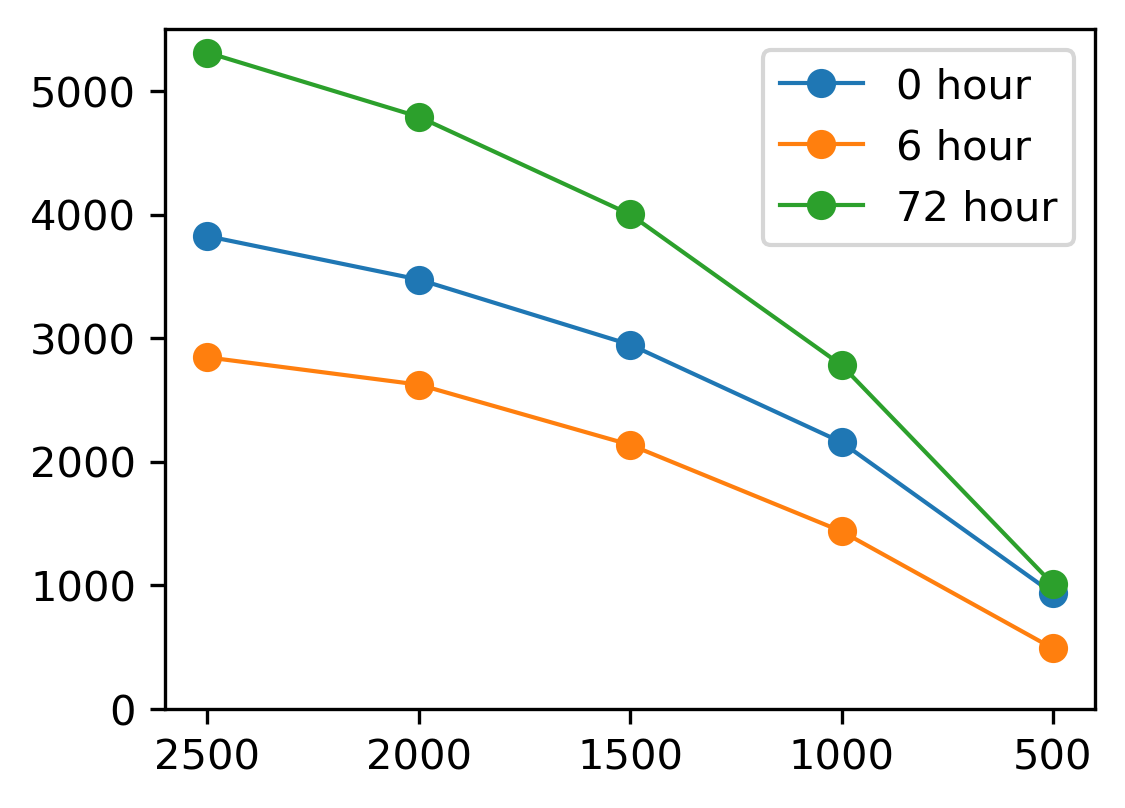

In [5]:
import matplotlib.pyplot as plt

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

depth=['2500M','2000M','1500M','1000M','500M']
colors={'K562_0000min': '#1f77b4',
        'K562_0360min': '#ff7f0e',
        'K562_4320min': '#2ca02c'}
legend_labels={'K562_0000min': '0 hour',
               'K562_0360min': '6 hour',
               'K562_4320min': '72 hour'}

plt.figure(figsize=(4, 3), dpi=300)
legend_handles=[]
for cond in conditions:
    num_fine_tune=[]
    for dep in depth:
        num_fine_tune.append(len(overlapped_loops_per_depth[dep][cond]['new_in_both']))
    plt.plot([-int(dep.replace("M", "")) for dep in depth], num_fine_tune, color=colors[cond], linestyle='-', linewidth=1, marker='o')
    legend_handles.append(plt.Line2D([0], [0], color=colors[cond], linestyle='-', linewidth=1, marker='o', label=legend_labels[cond]))

# Add legends
# plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=10)
plt.legend(handles=legend_handles, ncol=1, loc='upper right')
x_ticks = [-int(dep.replace("M", "")) for dep in depth]
plt.xticks(x_ticks, [dep.replace("M", "") for dep in depth])
plt.yticks(range(0,6000,1000))
plt.ylim(0,5500)

# plt.title('Fine-tuned loops')
# plt.xlabel('Number of valid intra-chromosomal reads in million per time point')
# plt.ylabel('Number of loops')
    
# # Save svg
# plt.savefig('/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/line_plot_of_numbers_of_overlapped_loops_per_depth.svg', format='svg', bbox_inches='tight')



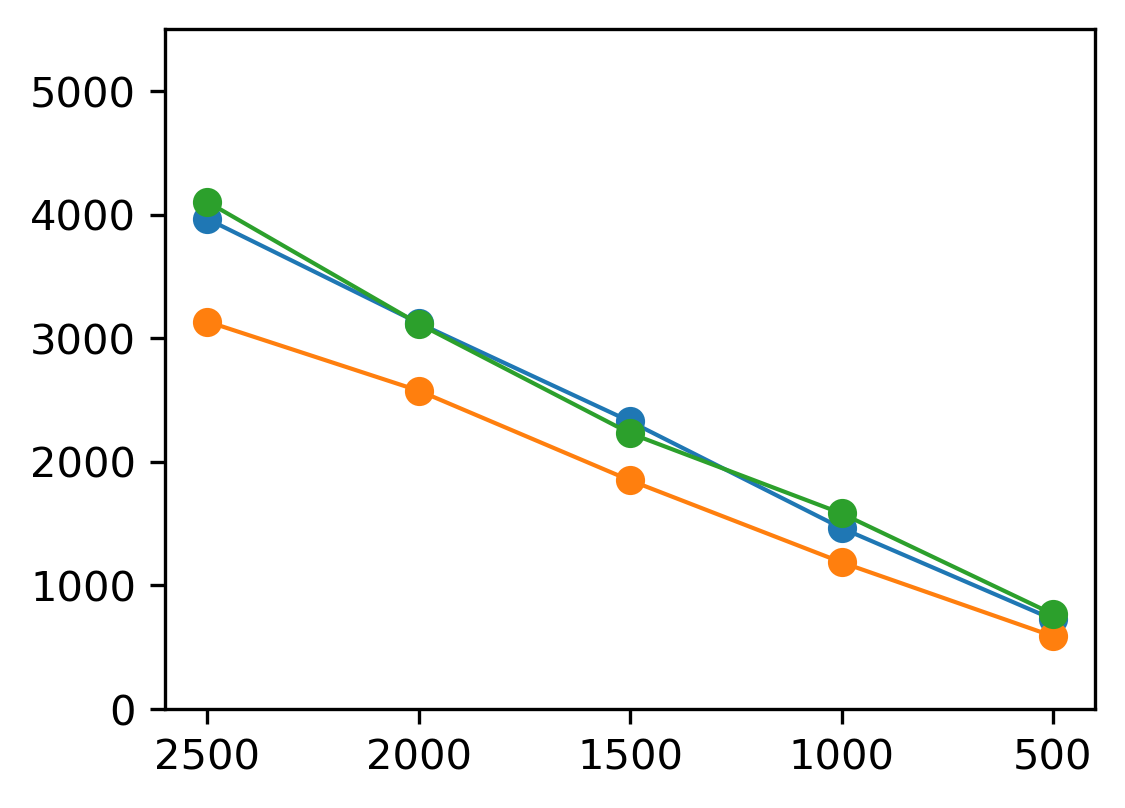

In [6]:
import matplotlib.pyplot as plt

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

depth=['2500M','2000M','1500M','1000M','500M']
colors={'K562_0000min': '#1f77b4',
        'K562_0360min': '#ff7f0e',
        'K562_4320min': '#2ca02c'}
legend_labels={'K562_0000min': '0 hour',
               'K562_0360min': '6 hour',
               'K562_4320min': '72 hour'}

plt.figure(figsize=(4, 3), dpi=300)
legend_handles=[]
for cond in conditions:
    num_new_only=[]
    for dep in depth:
        num_new_only.append(len(overlapped_loops_per_depth[dep][cond]['new_only_in_new']))
    plt.plot([-int(dep.replace("M", "")) for dep in depth], num_new_only, color=colors[cond], linestyle='-', linewidth=1, marker='o')
    legend_handles.append(plt.Line2D([0], [0], color=colors[cond], linestyle='-', linewidth=1, marker='o', label=legend_labels[cond]))

# Add legends
# plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=10)
# plt.legend(handles=legend_handles, ncol=1, loc='upper right')
x_ticks = [-int(dep.replace("M", "")) for dep in depth]
plt.xticks(x_ticks, [dep.replace("M", "") for dep in depth])
plt.yticks(range(0,6000,1000))
plt.ylim(0,5500)

# plt.title('Rescued loops')
# plt.xlabel('Number of valid intra-chromosomal reads in million per time point')
# plt.ylabel('Number of loops')
    
# # Save svg
# plt.savefig('/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/line_plot_of_numbers_of_rescued_loops_per_depth.svg', format='svg', bbox_inches='tight')


## Compare percentage of 5kb anchors overlapped with CNR peaks at different depths

In [7]:
# merged peak files CNR (two replicates)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

CNR_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/'
ctcf_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

# Note: K562_0360min does not have rad21 data
rad21_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

atac_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/ATAC_Seq/merged/'
atac_peak_file={
    'K562_0000min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

methods=['old_in_both', 'new_in_both', 'new_only_in_old_no_filtering', 'new_only_in_new']
depth=['2500M','2000M','1500M','1000M','500M']

In [8]:
import bioframe
import pandas as pd
import numpy as np
# margin=2500
# 5kb loop anchors
def calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors, margin=2500):
    anchors_overlapped_with_peaks={'condition': [],
                                   'method': [],
                                   'count': [],
                                   'total': [],
                                   'percent': []
                                  }

    for cond in conditions:
        for method in methods:
            anchors_overlapped_with_peaks['condition'].append(cond)
            anchors_overlapped_with_peaks['method'].append(method)
            anchors=all_anchors.loc[(all_anchors.condition == cond) & (all_anchors.method == method), ['chrom','start','end']]
            anchors['start']=((anchors['start']+anchors['end'])/2)-margin
            anchors['end']=((anchors['start']+anchors['end'])/2)+margin
            anchors['start']=anchors['start'].astype(int)
            anchors['end']=anchors['end'].astype(int)
            anchors_overlapped_with_peaks['total'].append(len(anchors))

            peak_df=pd.read_csv(peak_file[cond],sep='\t',header=None).iloc[:,:3]
            peak_df.columns=['chrom','start','end']
            overlapped_anchors=bioframe.overlap(anchors, peak_df, how='inner', suffixes=("","_"))[['chrom','start','end']].drop_duplicates().reset_index(drop=True)    
            anchors_overlapped_with_peaks['count'].append(len(overlapped_anchors))
            anchors_overlapped_with_peaks['percent'].append(100*len(overlapped_anchors)/len(anchors))

    anchors_overlapped_with_peaks=pd.DataFrame(anchors_overlapped_with_peaks)
    return anchors_overlapped_with_peaks
    

In [9]:
all_anchors_per_depth={}
for dep in depth:
    all_anchors=[]
    for cond in conditions:
        for method in methods:
            loops_df=overlapped_loops_per_depth[dep][cond][method][['chrom1','start1','end1','chrom2','start2','end2']].copy().reset_index(drop=True)
            anchor1=loops_df[['chrom1','start1','end1']].copy().set_axis(['chrom','start','end'], axis=1)
            anchor2=loops_df[['chrom2','start2','end2']].copy().set_axis(['chrom','start','end'], axis=1)
            anchors=pd.concat([anchor1, anchor2], ignore_index=True).drop_duplicates().reset_index(drop=True)
            anchors['condition']=cond
            anchors['method']=method
            all_anchors.append(anchors)
    all_anchors=pd.concat(all_anchors, ignore_index=True)
    all_anchors['depth']=dep
    all_anchors_per_depth[dep]=all_anchors
    

In [10]:
# CTCF
peak_file=ctcf_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_CTCF_peaks=[]
for dep in depth:
    df=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors_per_depth[dep])
    df['depth']=dep
    anchors_overlapped_with_CTCF_peaks.append(df)
anchors_overlapped_with_CTCF_peaks=pd.concat(anchors_overlapped_with_CTCF_peaks, ignore_index=True)

# Rad21
# No K562_0360min
peak_file=rad21_peak_file
conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_rad21_peaks=[]
for dep in depth:
    df=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors_per_depth[dep])
    df['depth']=dep
    anchors_overlapped_with_rad21_peaks.append(df)
anchors_overlapped_with_rad21_peaks=pd.concat(anchors_overlapped_with_rad21_peaks, ignore_index=True)

# atac
peak_file=atac_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_atac_peaks=[]
for dep in depth:
    df=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors_per_depth[dep])
    df['depth']=dep
    anchors_overlapped_with_atac_peaks.append(df)
anchors_overlapped_with_atac_peaks=pd.concat(anchors_overlapped_with_atac_peaks, ignore_index=True)


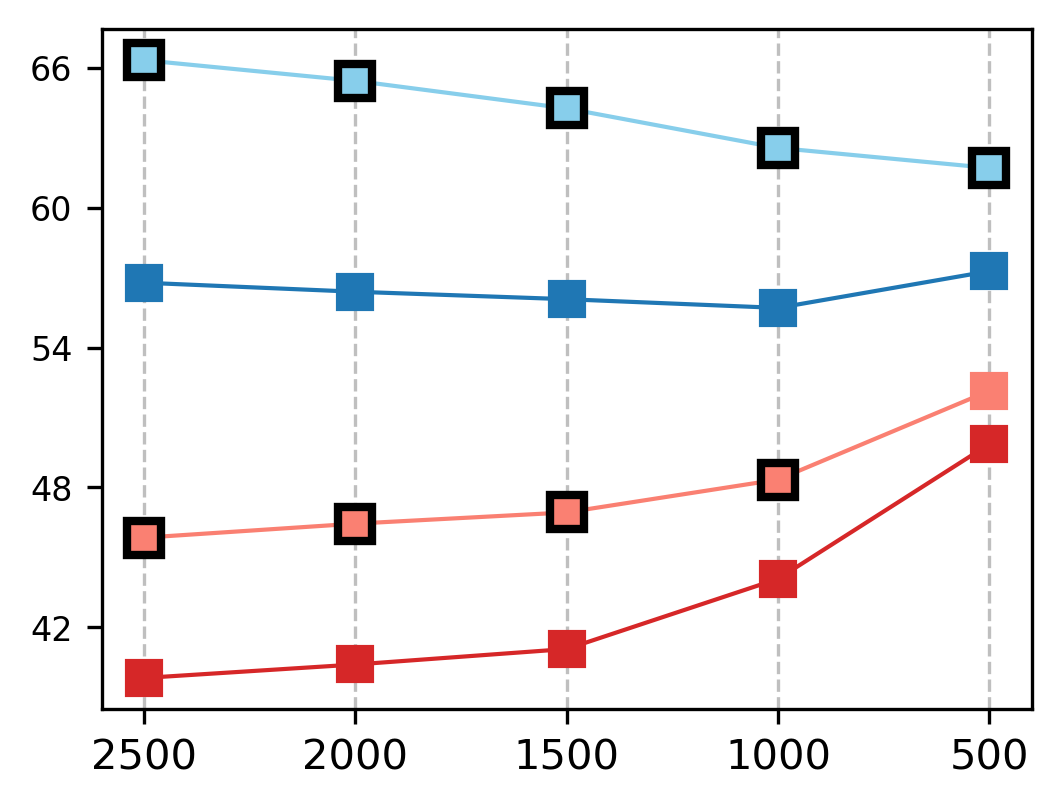

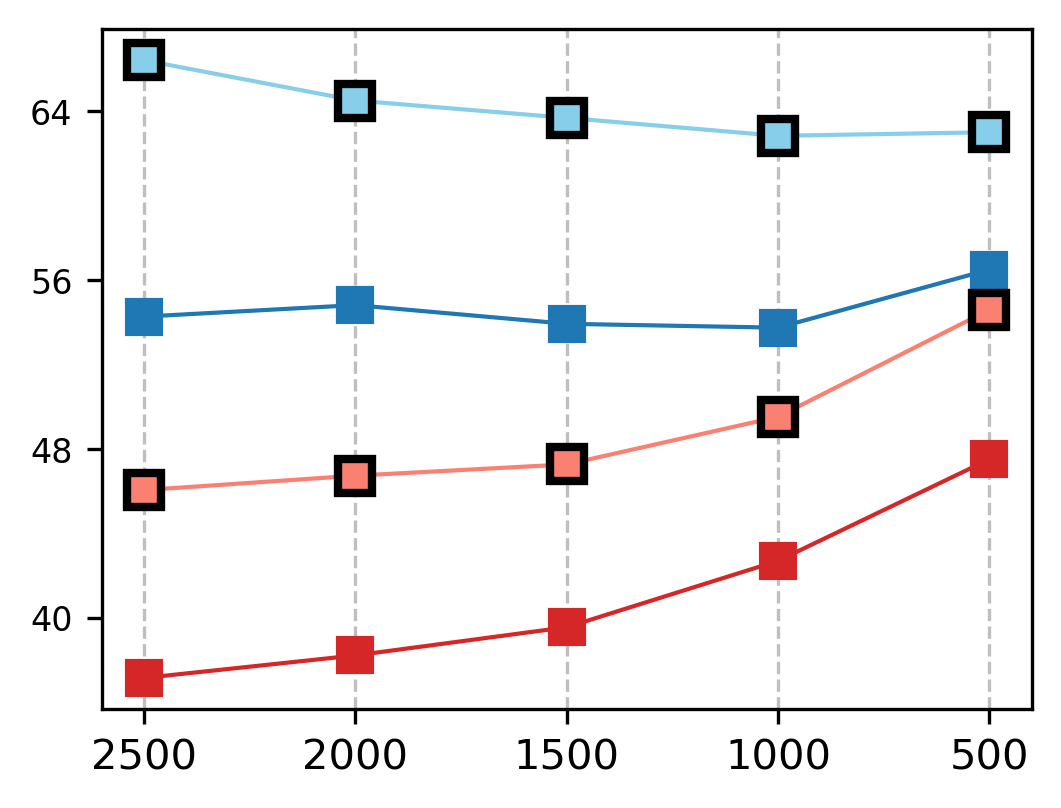

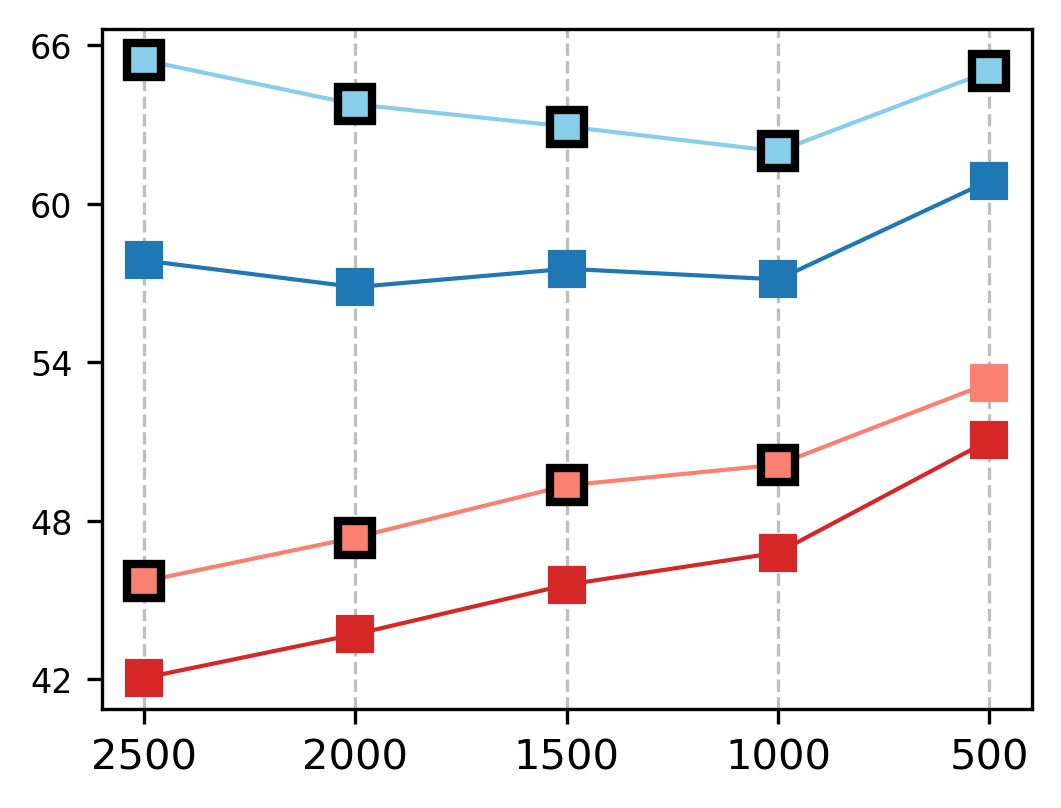

In [14]:
# CTCF

from scipy.stats import chi2_contingency
from matplotlib.ticker import MaxNLocator

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

anchors_overlapped_with_peaks=anchors_overlapped_with_CTCF_peaks

for cond in conditions:
    df=anchors_overlapped_with_peaks.loc[anchors_overlapped_with_peaks.condition == cond]
    percent_before_fine_tune=[]
    percent_after_fine_tune=[]
    percent_rescued_in_old_no_filtering=[]
    percent_rescued=[]
    for dep in depth:
        percent_before_fine_tune.append(df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'percent'].reset_index(drop=True)[0])
        percent_after_fine_tune.append(df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'percent'].reset_index(drop=True)[0])
        percent_rescued_in_old_no_filtering.append(df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'percent'].reset_index(drop=True)[0])
        percent_rescued.append(df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'percent'].reset_index(drop=True)[0])


    plt.figure(figsize=(4, 3), dpi=300)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) # set maximum of 5 y-ticks
    
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_before_fine_tune, color='#1f77b4', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_after_fine_tune, color='skyblue', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_rescued_in_old_no_filtering, color='#d62728', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_rescued, color='salmon', linestyle='-', linewidth=1, marker='s', markersize=8)
    x_ticks = [-int(dep.replace("M", "")) for dep in depth]
    plt.xticks(x_ticks, [dep.replace("M", "") for dep in depth])
    plt.yticks(fontsize=8)
    
    percent_after_fine_tune_copy=percent_after_fine_tune.copy()
    percent_rescued_copy=percent_rescued.copy()
    
    # chi2 test (old_in_both vs new_in_both)
    signif_indices=[]
    for i, dep in enumerate(depth):
        percent_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'percent'].reset_index(drop=True)[0]
        percent_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'percent'].reset_index(drop=True)[0]
        count_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'count'].reset_index(drop=True)[0]
        count_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'count'].reset_index(drop=True)[0]
        total_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'total'].reset_index(drop=True)[0]
        total_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'total'].reset_index(drop=True)[0]
        stat, p, dof, expected = chi2_contingency([[count_before_fine_tune, total_before_fine_tune-count_before_fine_tune], 
                                                   [count_after_fine_tune, total_after_fine_tune-count_after_fine_tune]])
        if p < 0.05:
            signif_indices.append(i)
            
    plt.plot(
        [[-int(dep.replace("M", "")) for dep in depth][i] for i in signif_indices],
        [percent_after_fine_tune_copy[i] for i in signif_indices],
        marker='s',
        linestyle='None',
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=2,
        markersize=8
    )
    
    
    # chi2 test (new_only_in_old_no_filtering vs new_only_in_new)
    signif_indices=[]
    for i, dep in enumerate(depth):
        percent_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'percent'].reset_index(drop=True)[0]
        percent_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'percent'].reset_index(drop=True)[0]
        count_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'count'].reset_index(drop=True)[0]
        count_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'count'].reset_index(drop=True)[0]
        total_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'total'].reset_index(drop=True)[0]
        total_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'total'].reset_index(drop=True)[0]
        stat, p, dof, expected = chi2_contingency([[count_after_fine_tune, total_after_fine_tune-count_after_fine_tune], 
                                                   [count_rescued, total_rescued-count_rescued]])
        if p < 0.05:
            signif_indices.append(i)
            
    plt.plot(
        [[-int(dep.replace("M", "")) for dep in depth][i] for i in signif_indices],
        [percent_rescued_copy[i] for i in signif_indices],
        marker='s',
        linestyle='None',
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=2,
        markersize=8
    )
        
        
#     if cond == conditions[0]:
#         # Add legends
#         before_fine_tune_line = plt.Line2D([0], [0], color='#1f77b4', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (before fine-tuning)')
#         after_fine_tune_line = plt.Line2D([0], [0], color='skyblue', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (after fine-tuning)')
#         rescued_in_old_no_filtering_line = plt.Line2D([0], [0], color='#d62728', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (before fine-tuning)')
#         rescued_line = plt.Line2D([0], [0], color='salmon', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (after fine-tuning)')
# #         # Add legend entries for marker types only
# #         # significant
# #         filled_marker = plt.Line2D(
# #             [0], [0],
# #             linestyle='None', marker='s',
# #             markerfacecolor='black', markeredgecolor='black',
# #             label='Significant'
# #         )
#         # not significant
#         hollow_marker = plt.Line2D(
#             [0], [0],
#             linestyle='None', marker='s',
#             markerfacecolor='none', markeredgecolor='black',
#             markeredgewidth=0.5,
#             markersize=8,
#             label='Significant'
#         )
#         legend_handles=[before_fine_tune_line, after_fine_tune_line, rescued_in_old_no_filtering_line, rescued_line, hollow_marker]
#         plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8)
        
#         plt.text(-2030, 68.8, 'Chi-square test relative to after fine-tuning\n*: significantly different\nns: non-significantly different', ha='left', fontsize=7, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))
    
#     plt.title(f'{cond} (CTCF)')
#     plt.xlabel('Number of valid intra-chromosomal reads in million')
#     plt.ylabel('Percentage')
    plt.grid(axis='x', linestyle='--', color='gray', alpha=0.5)
    
#     # Save svg
#     plt.savefig(f'/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/line_plot_of_percentage_of_5kb_anchors_overlapped_with_CTCF_CNR_peaks_at_{cond}_per_depth.svg', format='svg', bbox_inches='tight')

    

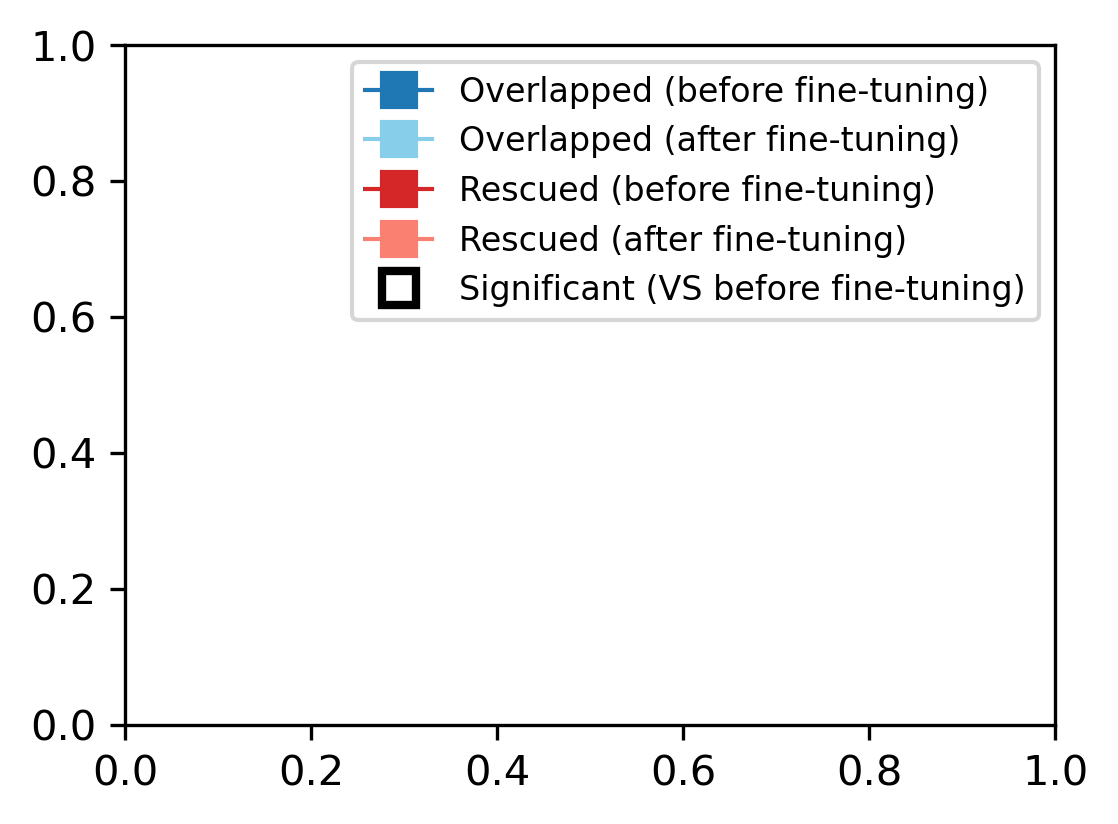

In [15]:
plt.figure(figsize=(4, 3), dpi=300)

before_fine_tune_line = plt.Line2D([0], [0], color='#1f77b4', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (before fine-tuning)')
after_fine_tune_line = plt.Line2D([0], [0], color='skyblue', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (after fine-tuning)')
rescued_in_old_no_filtering_line = plt.Line2D([0], [0], color='#d62728', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (before fine-tuning)')
rescued_line = plt.Line2D([0], [0], color='salmon', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (after fine-tuning)')

hollow_marker = plt.Line2D(
    [0], [0],
    linestyle='None', marker='s',
    markerfacecolor='none', markeredgecolor='black',
    markeredgewidth=2,
    markersize=8,
    label='Significant (VS before fine-tuning)'
)
legend_handles=[before_fine_tune_line, after_fine_tune_line, rescued_in_old_no_filtering_line, rescued_line, hollow_marker]
plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8)

# # Save svg
# plt.savefig(f'/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/legend_of_line_plot_of_percentage_of_5kb_anchors_overlapped_with_peaks_per_depth.svg', format='svg', bbox_inches='tight')


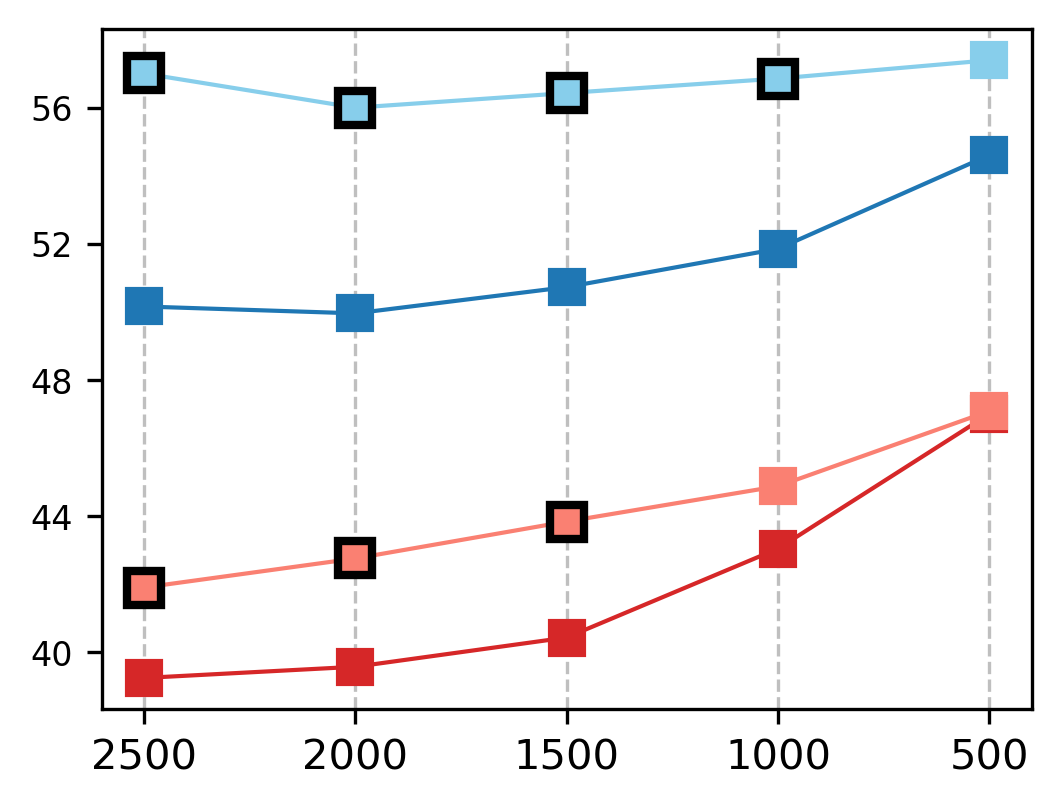

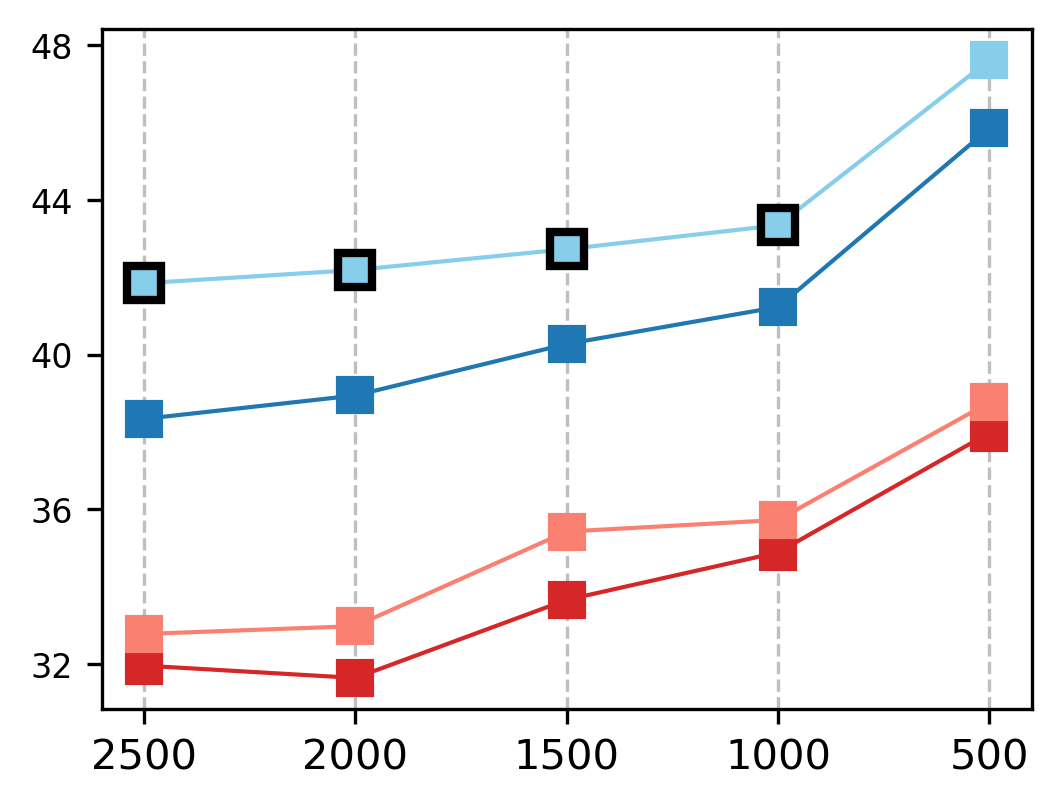

In [16]:
# rad21

from scipy.stats import chi2_contingency
from matplotlib.ticker import MaxNLocator

conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']

anchors_overlapped_with_peaks=anchors_overlapped_with_rad21_peaks

for cond in conditions:
    df=anchors_overlapped_with_peaks.loc[anchors_overlapped_with_peaks.condition == cond]
    percent_before_fine_tune=[]
    percent_after_fine_tune=[]
    percent_rescued_in_old_no_filtering=[]
    percent_rescued=[]
    for dep in depth:
        percent_before_fine_tune.append(df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'percent'].reset_index(drop=True)[0])
        percent_after_fine_tune.append(df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'percent'].reset_index(drop=True)[0])
        percent_rescued_in_old_no_filtering.append(df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'percent'].reset_index(drop=True)[0])
        percent_rescued.append(df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'percent'].reset_index(drop=True)[0])


    plt.figure(figsize=(4, 3), dpi=300)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) # set maximum of 5 y-ticks
    
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_before_fine_tune, color='#1f77b4', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_after_fine_tune, color='skyblue', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_rescued_in_old_no_filtering, color='#d62728', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_rescued, color='salmon', linestyle='-', linewidth=1, marker='s', markersize=8)
    x_ticks = [-int(dep.replace("M", "")) for dep in depth]
    plt.xticks(x_ticks, [dep.replace("M", "") for dep in depth])
    plt.yticks(fontsize=8)
    
    percent_after_fine_tune_copy=percent_after_fine_tune.copy()
    percent_rescued_copy=percent_rescued.copy()
    
    # chi2 test (old_in_both vs new_in_both)
    signif_indices=[]
    for i, dep in enumerate(depth):
        percent_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'percent'].reset_index(drop=True)[0]
        percent_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'percent'].reset_index(drop=True)[0]
        count_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'count'].reset_index(drop=True)[0]
        count_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'count'].reset_index(drop=True)[0]
        total_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'total'].reset_index(drop=True)[0]
        total_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'total'].reset_index(drop=True)[0]
        stat, p, dof, expected = chi2_contingency([[count_before_fine_tune, total_before_fine_tune-count_before_fine_tune], 
                                                   [count_after_fine_tune, total_after_fine_tune-count_after_fine_tune]])
        if p < 0.05:
            signif_indices.append(i)
            
    plt.plot(
        [[-int(dep.replace("M", "")) for dep in depth][i] for i in signif_indices],
        [percent_after_fine_tune_copy[i] for i in signif_indices],
        marker='s',
        linestyle='None',
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=2,
        markersize=8
    )
    
    
    # chi2 test (new_only_in_old_no_filtering vs new_only_in_new)
    signif_indices=[]
    for i, dep in enumerate(depth):
        percent_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'percent'].reset_index(drop=True)[0]
        percent_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'percent'].reset_index(drop=True)[0]
        count_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'count'].reset_index(drop=True)[0]
        count_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'count'].reset_index(drop=True)[0]
        total_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'total'].reset_index(drop=True)[0]
        total_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'total'].reset_index(drop=True)[0]
        stat, p, dof, expected = chi2_contingency([[count_after_fine_tune, total_after_fine_tune-count_after_fine_tune], 
                                                   [count_rescued, total_rescued-count_rescued]])
        if p < 0.05:
            signif_indices.append(i)
            
    plt.plot(
        [[-int(dep.replace("M", "")) for dep in depth][i] for i in signif_indices],
        [percent_rescued_copy[i] for i in signif_indices],
        marker='s',
        linestyle='None',
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=2,
        markersize=8
    )
        
        
#     if cond == conditions[0]:
#         # Add legends
#         before_fine_tune_line = plt.Line2D([0], [0], color='#1f77b4', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (before fine-tuning)')
#         after_fine_tune_line = plt.Line2D([0], [0], color='skyblue', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (after fine-tuning)')
#         rescued_in_old_no_filtering_line = plt.Line2D([0], [0], color='#d62728', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (before fine-tuning)')
#         rescued_line = plt.Line2D([0], [0], color='salmon', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (after fine-tuning)')
# #         # Add legend entries for marker types only
# #         # significant
# #         filled_marker = plt.Line2D(
# #             [0], [0],
# #             linestyle='None', marker='s',
# #             markerfacecolor='black', markeredgecolor='black',
# #             label='Significant'
# #         )
#         # not significant
#         hollow_marker = plt.Line2D(
#             [0], [0],
#             linestyle='None', marker='s',
#             markerfacecolor='none', markeredgecolor='black',
#             markeredgewidth=0.5,
#             markersize=8,
#             label='Significant'
#         )
#         legend_handles=[before_fine_tune_line, after_fine_tune_line, rescued_in_old_no_filtering_line, rescued_line, hollow_marker]
#         plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8)
        
#         plt.text(-2030, 68.8, 'Chi-square test relative to after fine-tuning\n*: significantly different\nns: non-significantly different', ha='left', fontsize=7, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))
    
#     plt.title(f'{cond} (rad21)')
#     plt.xlabel('Number of valid intra-chromosomal reads in million')
#     plt.ylabel('Percentage')
    plt.grid(axis='x', linestyle='--', color='gray', alpha=0.5)
    
#     # Save svg
#     plt.savefig(f'/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/line_plot_of_percentage_of_5kb_anchors_overlapped_with_Rad21_CNR_peaks_at_{cond}_per_depth.svg', format='svg', bbox_inches='tight')

    

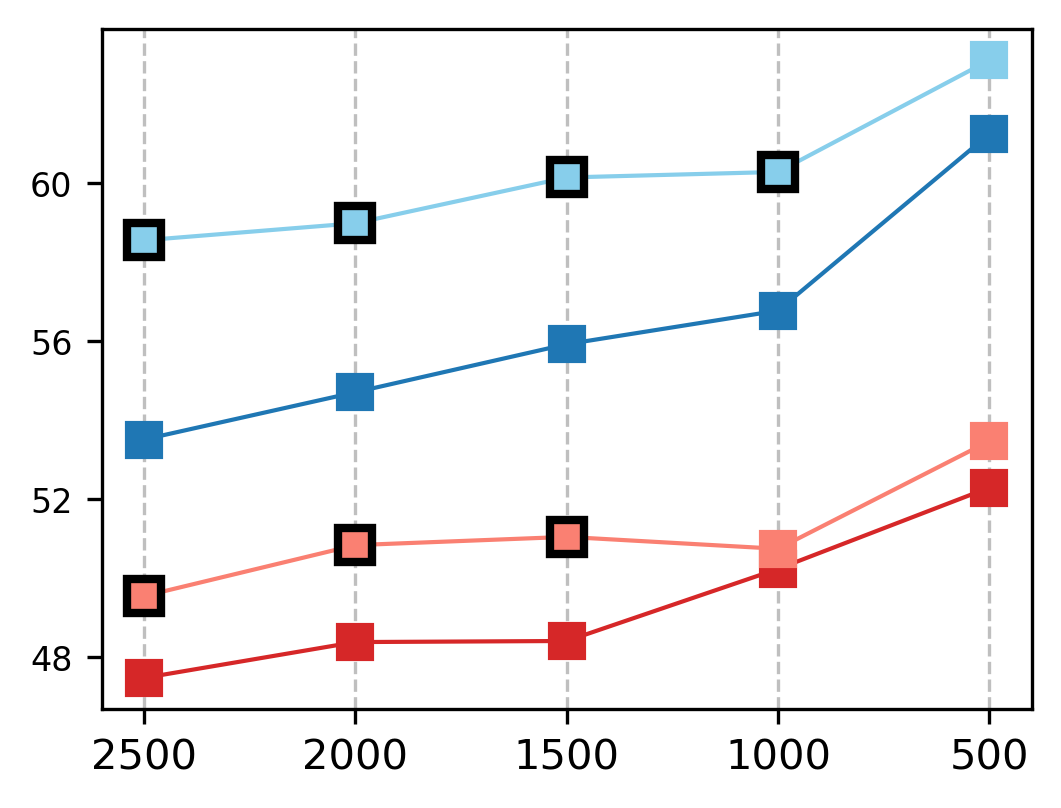

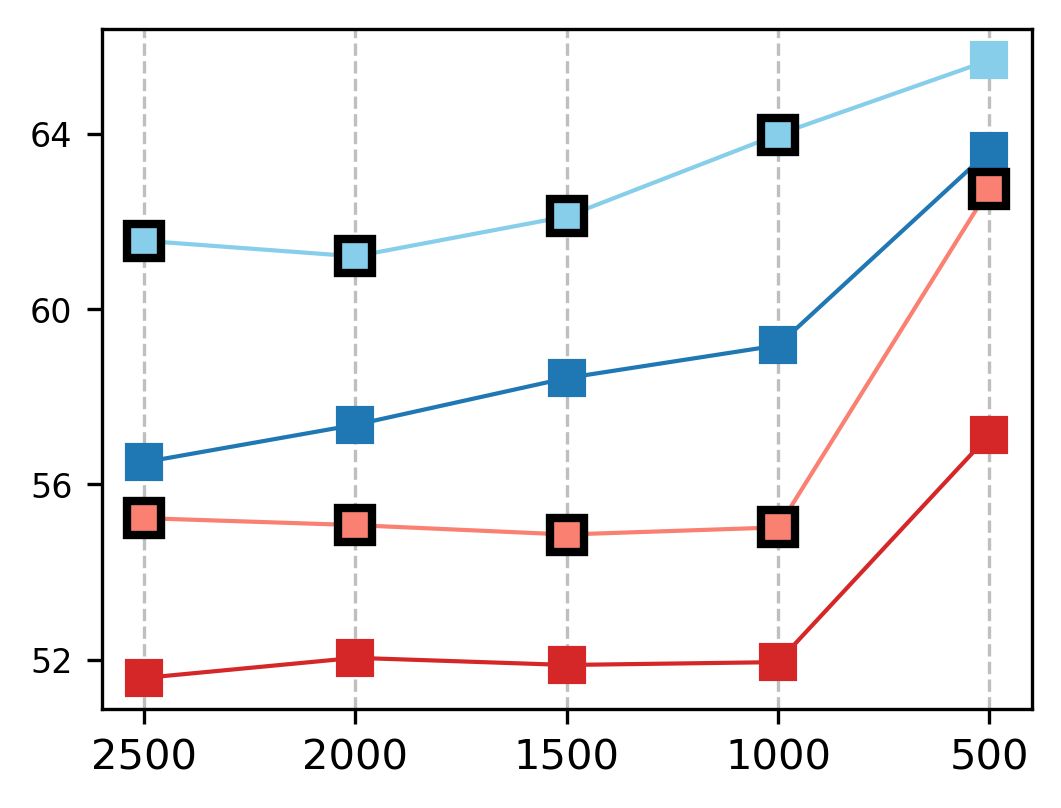

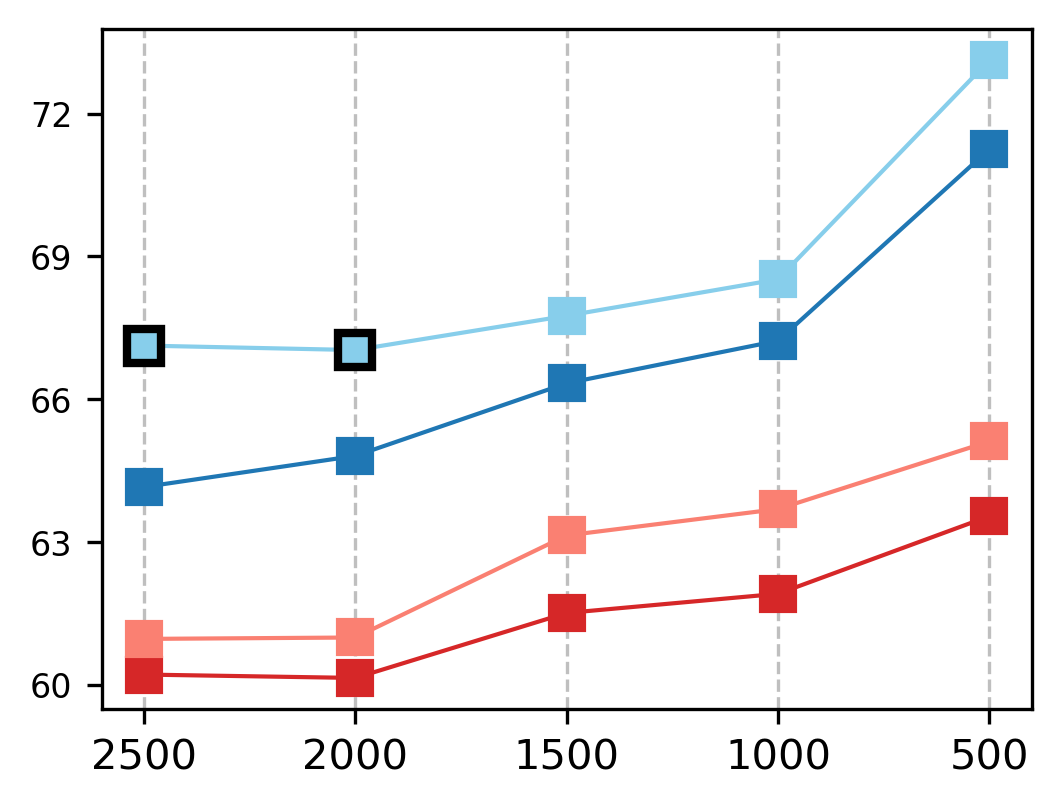

In [18]:
# atac

from scipy.stats import chi2_contingency
from matplotlib.ticker import MaxNLocator

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

anchors_overlapped_with_peaks=anchors_overlapped_with_atac_peaks

for cond in conditions:
    df=anchors_overlapped_with_peaks.loc[anchors_overlapped_with_peaks.condition == cond]
    percent_before_fine_tune=[]
    percent_after_fine_tune=[]
    percent_rescued_in_old_no_filtering=[]
    percent_rescued=[]
    for dep in depth:
        percent_before_fine_tune.append(df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'percent'].reset_index(drop=True)[0])
        percent_after_fine_tune.append(df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'percent'].reset_index(drop=True)[0])
        percent_rescued_in_old_no_filtering.append(df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'percent'].reset_index(drop=True)[0])
        percent_rescued.append(df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'percent'].reset_index(drop=True)[0])


    plt.figure(figsize=(4, 3), dpi=300)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) # set maximum of 5 y-ticks
    
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_before_fine_tune, color='#1f77b4', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_after_fine_tune, color='skyblue', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_rescued_in_old_no_filtering, color='#d62728', linestyle='-', linewidth=1, marker='s', markersize=8)
    plt.plot([-int(dep.replace("M", "")) for dep in depth], percent_rescued, color='salmon', linestyle='-', linewidth=1, marker='s', markersize=8)
    x_ticks = [-int(dep.replace("M", "")) for dep in depth]
    plt.xticks(x_ticks, [dep.replace("M", "") for dep in depth])
    plt.yticks(fontsize=8)
    
    percent_after_fine_tune_copy=percent_after_fine_tune.copy()
    percent_rescued_copy=percent_rescued.copy()
    
    # chi2 test (old_in_both vs new_in_both)
    signif_indices=[]
    for i, dep in enumerate(depth):
        percent_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'percent'].reset_index(drop=True)[0]
        percent_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'percent'].reset_index(drop=True)[0]
        count_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'count'].reset_index(drop=True)[0]
        count_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'count'].reset_index(drop=True)[0]
        total_before_fine_tune=df.loc[(df.depth == dep) & (df.method == 'old_in_both'),'total'].reset_index(drop=True)[0]
        total_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_in_both'),'total'].reset_index(drop=True)[0]
        stat, p, dof, expected = chi2_contingency([[count_before_fine_tune, total_before_fine_tune-count_before_fine_tune], 
                                                   [count_after_fine_tune, total_after_fine_tune-count_after_fine_tune]])
        if p < 0.05:
            signif_indices.append(i)
            
    plt.plot(
        [[-int(dep.replace("M", "")) for dep in depth][i] for i in signif_indices],
        [percent_after_fine_tune_copy[i] for i in signif_indices],
        marker='s',
        linestyle='None',
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=2,
        markersize=8
    )
    
    
    # chi2 test (new_only_in_old_no_filtering vs new_only_in_new)
    signif_indices=[]
    for i, dep in enumerate(depth):
        percent_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'percent'].reset_index(drop=True)[0]
        percent_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'percent'].reset_index(drop=True)[0]
        count_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'count'].reset_index(drop=True)[0]
        count_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'count'].reset_index(drop=True)[0]
        total_after_fine_tune=df.loc[(df.depth == dep) & (df.method == 'new_only_in_old_no_filtering'),'total'].reset_index(drop=True)[0]
        total_rescued=df.loc[(df.depth == dep) & (df.method == 'new_only_in_new'),'total'].reset_index(drop=True)[0]
        stat, p, dof, expected = chi2_contingency([[count_after_fine_tune, total_after_fine_tune-count_after_fine_tune], 
                                                   [count_rescued, total_rescued-count_rescued]])
        if p < 0.05:
            signif_indices.append(i)
            
    plt.plot(
        [[-int(dep.replace("M", "")) for dep in depth][i] for i in signif_indices],
        [percent_rescued_copy[i] for i in signif_indices],
        marker='s',
        linestyle='None',
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=2,
        markersize=8
    )
        
        
#     if cond == conditions[0]:
#         # Add legends
#         before_fine_tune_line = plt.Line2D([0], [0], color='#1f77b4', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (before fine-tuning)')
#         after_fine_tune_line = plt.Line2D([0], [0], color='skyblue', linestyle='-', linewidth=1, marker='s', markersize=8, label='Overlapped (after fine-tuning)')
#         rescued_in_old_no_filtering_line = plt.Line2D([0], [0], color='#d62728', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (before fine-tuning)')
#         rescued_line = plt.Line2D([0], [0], color='salmon', linestyle='-', linewidth=1, marker='s', markersize=8, label='Rescued (after fine-tuning)')
# #         # Add legend entries for marker types only
# #         # significant
# #         filled_marker = plt.Line2D(
# #             [0], [0],
# #             linestyle='None', marker='s',
# #             markerfacecolor='black', markeredgecolor='black',
# #             label='Significant'
# #         )
#         # not significant
#         hollow_marker = plt.Line2D(
#             [0], [0],
#             linestyle='None', marker='s',
#             markerfacecolor='none', markeredgecolor='black',
#             markeredgewidth=0.5,
#             markersize=8,
#             label='Significant'
#         )
#         legend_handles=[before_fine_tune_line, after_fine_tune_line, rescued_in_old_no_filtering_line, rescued_line, hollow_marker]
#         plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8)
        
#         plt.text(-2030, 68.8, 'Chi-square test relative to after fine-tuning\n*: significantly different\nns: non-significantly different', ha='left', fontsize=7, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))
    
#     plt.title(f'{cond} (atac)')
#     plt.xlabel('Number of valid intra-chromosomal reads in million')
#     plt.ylabel('Percentage')
    plt.grid(axis='x', linestyle='--', color='gray', alpha=0.5)
    
#     # Save svg
#     plt.savefig(f'/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/line_plot_of_percentage_of_5kb_anchors_overlapped_with_ATAC_Seq_peaks_at_{cond}_per_depth.svg', format='svg', bbox_inches='tight')

    

### Compare distributions of loop size between overlapped and rescued loops at different depths.

In [32]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
depth=['2500M','2000M','1500M','1000M','500M']
methods=['new_in_both','new_only_in_new']
loop_size_list=[]
for dep in depth:
    for cond in conditions:
        for method in methods:
            df=overlapped_loops_per_depth[dep][cond][method][['chrom1','start1','end1','chrom2','start2','end2']]
            df['method']=method
            df['condition']=cond
            df['loop_size']=df['start2']-df['start1']
            df['depth']=dep
            loop_size_list.append(df)
            
loop_size_df=pd.concat(loop_size_list)




/tmp/ipykernel_3906253/2125473758.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['method']=method
/tmp/ipykernel_3906253/2125473758.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['condition']=cond


In [33]:
# The Wilcoxon rank-sum test tests the null hypothesis that two sets of measurements are drawn 
# from the same distribution. The alternative hypothesis is that values in one sample are more 
# likely to be larger than the values in the other sample.

# The Wilcoxon Rank-Sum test is still valid for data from any distribution, whether Normal or not, and 
# is much less sensitive to outliers than the two-sample t-test.

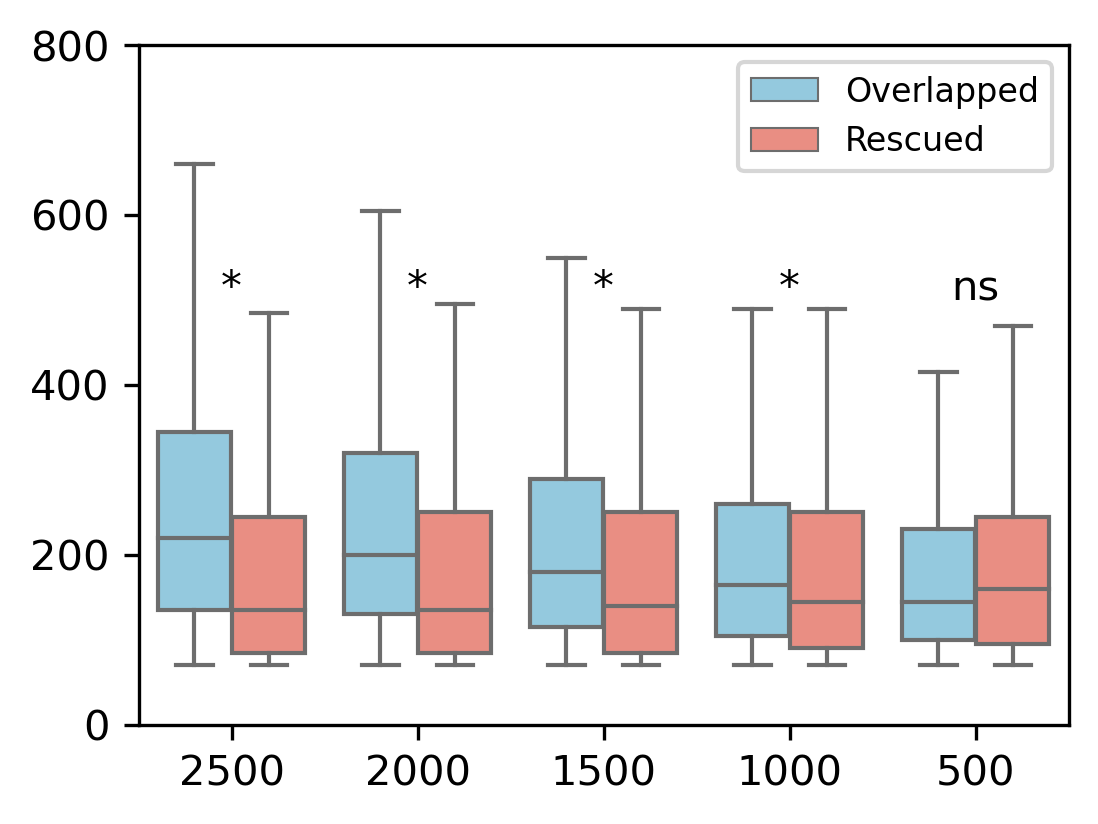

In [35]:
# K562_0000min
from scipy.stats import ranksums
import seaborn as sns

fig = plt.figure(dpi=300, figsize=(4,3))
sns.set_palette(('skyblue','salmon'))
data=loop_size_df.loc[loop_size_df.condition == 'K562_0000min']
ax=sns.boxplot(x='depth', y='loop_size', hue='method', showfliers=False, data=data, linewidth=1)
ax.set(xlabel=None)
# ax.set_ylabel('Loop size (kb)', size=12)
ax.set_ylabel('', size=12)
ax.set_yticks(range(0, 900000, 200000))
ax.set_yticklabels(range(0, 900, 200), fontsize=10)
ax.set_xticks(range(len(depth)))
ax.set_xticklabels([dep.replace('M','') for dep in depth], fontsize=10)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Overlapped', 'Rescued'], loc='upper right', ncol=1, fontsize=8)
# ax.legend_.remove()
# ax.set_title('K562_0000min')
# ax.set_xlabel('Number of valid intra-chromosomal reads in million', fontsize=10)

for i in range(len(depth)):
    p=ranksums(data.loc[(data['depth'] == depth[i]) & (data['method'] == 'new_in_both'), 'loop_size'], 
               data.loc[(data['depth'] == depth[i]) & (data['method'] == 'new_only_in_new'), 'loop_size']).pvalue
    p_label='*' if p < 0.05 else 'ns'
    ax.text(i, 500000, p_label, ha='center', fontsize=10)

# # Save svg
# plt.savefig(f'/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/box_plot_of_size_of_overlapped_and_rescued_loops_at_K562_0000min_per_depth.svg', format='svg', bbox_inches='tight')


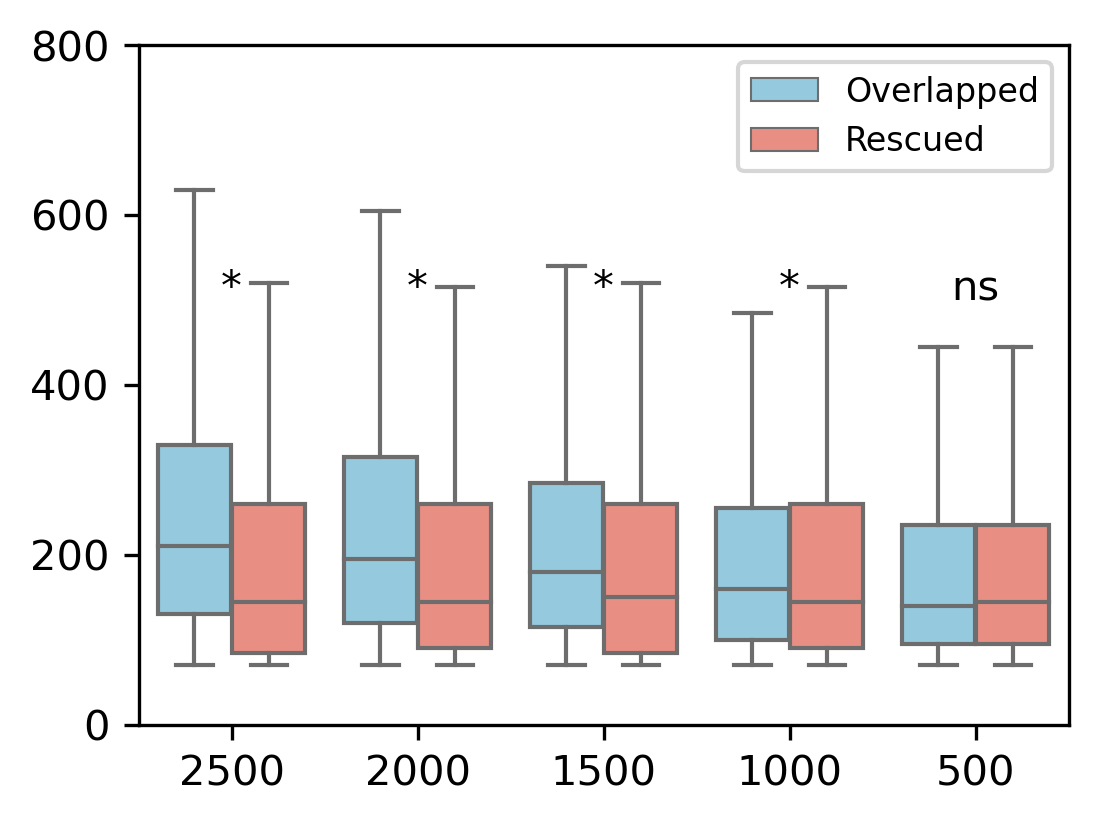

In [36]:
# K562_0360min
from scipy.stats import ranksums
import seaborn as sns

fig = plt.figure(dpi=300, figsize=(4,3))
sns.set_palette(('skyblue','salmon'))
data=loop_size_df.loc[loop_size_df.condition == 'K562_0360min']
ax=sns.boxplot(x='depth', y='loop_size', hue='method', showfliers=False, data=data, linewidth=1)
ax.set(xlabel=None)
# ax.set_ylabel('Loop size (kb)', size=12)
ax.set_ylabel('', size=12)
ax.set_yticks(range(0, 900000, 200000))
ax.set_yticklabels(range(0, 900, 200), fontsize=10)
ax.set_xticks(range(len(depth)))
ax.set_xticklabels([dep.replace('M','') for dep in depth], fontsize=10)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Overlapped', 'Rescued'], loc='upper right', ncol=1, fontsize=8)
# ax.legend_.remove()
# ax.set_title('K562_0360min')
# ax.set_xlabel('Number of valid intra-chromosomal reads in million', fontsize=10)

for i in range(len(depth)):
    p=ranksums(data.loc[(data['depth'] == depth[i]) & (data['method'] == 'new_in_both'), 'loop_size'], 
               data.loc[(data['depth'] == depth[i]) & (data['method'] == 'new_only_in_new'), 'loop_size']).pvalue
    p_label='*' if p < 0.05 else 'ns'
    ax.text(i, 500000, p_label, ha='center', fontsize=10)

# # Save svg
# plt.savefig(f'/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/box_plot_of_size_of_overlapped_and_rescued_loops_at_K562_0360min_per_depth.svg', format='svg', bbox_inches='tight')


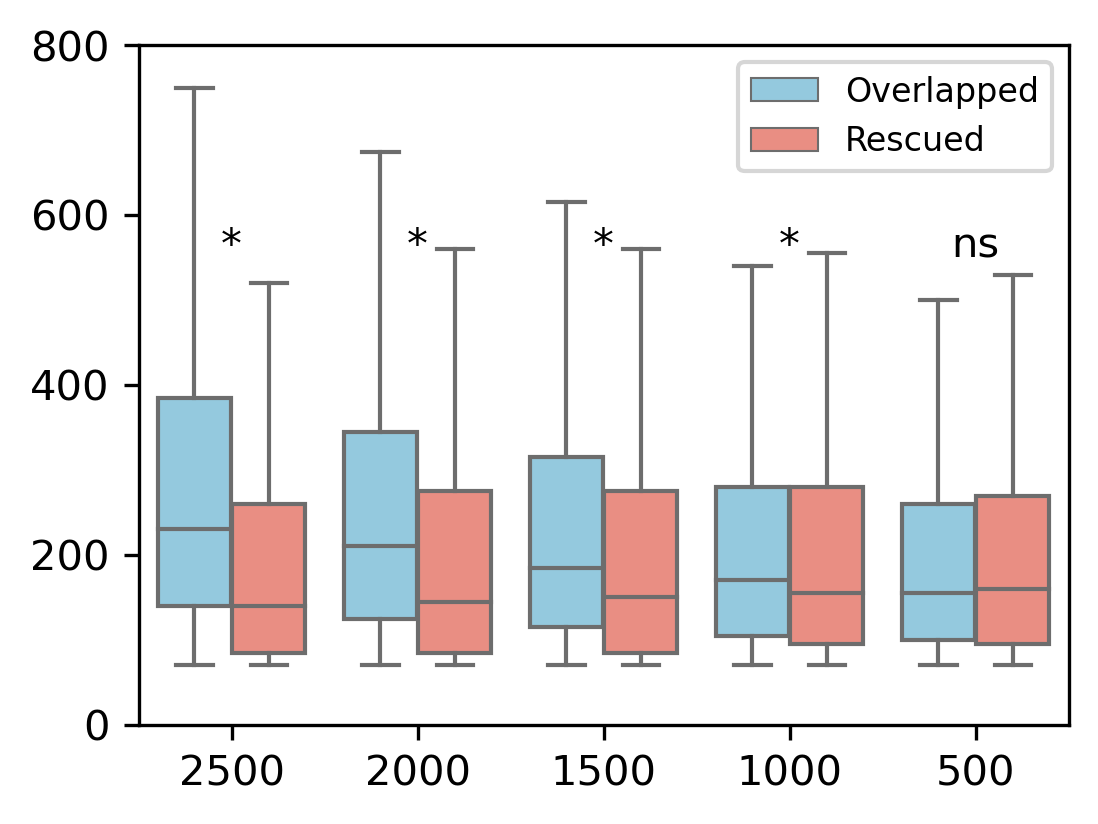

In [37]:
# K562_4320min
from scipy.stats import ranksums
import seaborn as sns

fig = plt.figure(dpi=300, figsize=(4,3))
sns.set_palette(('skyblue','salmon'))
data=loop_size_df.loc[loop_size_df.condition == 'K562_4320min']
ax=sns.boxplot(x='depth', y='loop_size', hue='method', showfliers=False, data=data, linewidth=1)
ax.set(xlabel=None)
# ax.set_ylabel('Loop size (kb)', size=12)
ax.set_ylabel('', size=12)
ax.set_yticks(range(0, 900000, 200000))
ax.set_yticklabels(range(0, 900, 200), fontsize=10)
ax.set_xticks(range(len(depth)))
ax.set_xticklabels([dep.replace('M','') for dep in depth], fontsize=10)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Overlapped', 'Rescued'], loc='upper right', ncol=1, fontsize=8)
# ax.legend_.remove()
# ax.set_title('K562_4320min')
# ax.set_xlabel('Number of valid intra-chromosomal reads in million', fontsize=10)

for i in range(len(depth)):
    p=ranksums(data.loc[(data['depth'] == depth[i]) & (data['method'] == 'new_in_both'), 'loop_size'], 
               data.loc[(data['depth'] == depth[i]) & (data['method'] == 'new_only_in_new'), 'loop_size']).pvalue
    p_label='*' if p < 0.05 else 'ns'
    ax.text(i, 550000, p_label, ha='center', fontsize=10)

# # Save svg
# plt.savefig(f'/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_6/box_plot_of_size_of_overlapped_and_rescued_loops_at_K562_4320min_per_depth.svg', format='svg', bbox_inches='tight')
